In [1]:
import pandas as pd
#from sentence_transformers import SentenceTransformer
import ast
from scipy.stats import entropy
from functools import partial
import numpy as np

In [2]:
df = pd.read_csv('../data/clipscore/main_clipscore_imageof.csv', index_col=0)

In [3]:
df = df.drop(labels=[1060])
df.index = list(range(len(df)))

In [4]:
df['clipscore_dict'] = df['clipscore'].apply(ast.literal_eval)


In [5]:
for i in range(len(df['clipscore_dict'])):
    item = df['clipscore_dict'][i]
    try:
        a = item['retrieval']['CLIPscore_lemma']
    except:
        num_obj = len(item['kandinsky-community_kandinsky-3']['CLIPscore_cohyponyms'])
        df['clipscore_dict'][i]['retrieval'] = {'CLIPscore_lemma': 0, 'CLIPscore_hypernyms': [0], 'CLIPscore_cohyponyms': [0]*num_obj}

In [15]:
# 1. Mean CLIPscore for lemma for each model over the entire dataset
def calculate_mean_lemma(df):
    mean_lemma_scores = {}
    for model in df['clipscore_dict'].iloc[0].keys():
        mean_lemma_scores[model] = df['clipscore_dict'].apply(lambda x: x[model]['CLIPscore_lemma']).mean()
    return mean_lemma_scores

# 1.2 Mean CLIPscore for lemma for each model over each subset
def calculate_mean_lemma_by_subset(df):
    mean_lemma_scores_by_subset = df.groupby('subset').apply(calculate_mean_lemma)
    return mean_lemma_scores_by_subset

# 2. Mean CLIPscore for hypernyms over the entire dataset
def calculate_mean_hypernyms(df):
    mean_hypernym_scores = {}
    for model in df['clipscore_dict'].iloc[0].keys():
        mean_hypernym_scores[model] = df['clipscore_dict'].apply(lambda x: np.mean(x[model]['CLIPscore_hypernyms'])).mean()
    return mean_hypernym_scores

# 2.2 Mean CLIPscore for hypernyms for each model over each subset
def calculate_mean_hypernyms_by_subset(df):
    mean_hypernym_scores_by_subset = df.groupby('subset').apply(calculate_mean_hypernyms)
    return mean_hypernym_scores_by_subset

# 3. Mean CLIPscore for cohyponyms over the entire dataset
def calculate_mean_cohyponyms(df):
    mean_cohyponym_scores = {}
    for model in df['clipscore_dict'].iloc[0].keys():
        mean_cohyponym_scores[model] = df['clipscore_dict'].apply(lambda x: np.mean(x[model]['CLIPscore_cohyponyms'])).mean()
    return mean_cohyponym_scores

# 3.2 Mean CLIPscore for cohyponyms for each model over each subset
def calculate_mean_cohyponyms_by_subset(df):
    mean_cohyponym_scores_by_subset = df.groupby('subset').apply(calculate_mean_cohyponyms)
    return mean_cohyponym_scores_by_subset

# 4. Entropy of cohyponyms score if there are multiple for all data and for each subset
def calculate_entropy_cohyponyms(df):
    entropy_scores = {}
    for model in df['clipscore_dict'].iloc[0].keys():
        entropies = df['clipscore_dict'].apply(lambda x: entropy(x[model]['CLIPscore_cohyponyms']) if len(x[model]['CLIPscore_cohyponyms']) > 1 else 0)
        df['entropy'] = entropies
        non_zero_entropies = entropies[entropies > 0]  # Filter out zero entropies
        if len(non_zero_entropies) > 0:
            entropy_scores[model] = non_zero_entropies.mean()
        else:
            entropy_scores[model] = 0  # Handle case where all entropies are zero
    return entropy_scores

def calculate_entropy_cohyponyms_by_subset(df):
    entropy_cohyponym_scores_by_subset = df.groupby('subset').apply(calculate_entropy_cohyponyms)
    return entropy_cohyponym_scores_by_subset

def max_of_cohyponyms(row, model):

    if len(row[model]['CLIPscore_cohyponyms']) > 1:
        max_cohyp = [score for score in row[model]['CLIPscore_cohyponyms'] if score != row[model]['CLIPscore_lemma']]
        if len(max_cohyp) == 0:
            return 0
        return row [model]['CLIPscore_lemma'] / np.mean(max_cohyp)
    else:
        return 0
def calculate_relation_lemma_max_cohyponym(df):
    relation_scores = {}
    for model in df['clipscore_dict'].iloc[0].keys():
        relations = df['clipscore_dict'].apply(partial(max_of_cohyponyms, model=model))
        non_zero_relations = relations[relations > 0]  # Filter out zero relations
        if len(non_zero_relations) > 0:
            relation_scores[model] = non_zero_relations.mean()
        else:
            relation_scores[model] = 0  # Handle case where all relations are zero or invalid
    return relation_scores

def calculate_relation_lemma_max_cohyponym_by_subset(df):
    relation_scores_by_subset = df.groupby('subset').apply(calculate_relation_lemma_max_cohyponym)
    return relation_scores_by_subset

def calculate_dist_relation_lemma_max_cohyponym(df):
    relation_scores = {}
    for model in df['clipscore_dict'].iloc[0].keys():
        relations = df['clipscore_dict'].apply(partial(max_of_cohyponyms, model=model))
        non_zero_relations = relations[relations > 0]  # Filter out zero relations
        if len(non_zero_relations) > 0:
            relation_scores[model] = non_zero_relations.values
        else:
            relation_scores[model] = 0  # Handle case where all relations are zero or invalid
    return relation_scores


In [10]:

# Compute results
mean_lemma_scores = calculate_mean_lemma(df)
mean_lemma_scores_by_subset = calculate_mean_lemma_by_subset(df)


mean_hypernym_scores = calculate_mean_hypernyms(df)
mean_hypernym_scores_by_subset = calculate_mean_hypernyms_by_subset(df)


mean_cohyponym_scores = calculate_mean_cohyponyms(df)
mean_cohyponym_scores_by_subset = calculate_mean_cohyponyms_by_subset(df)



/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.10/dist-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,


In [11]:

entropy_cohyponym_scores = calculate_entropy_cohyponyms(df)
entropy_cohyponym_scores_by_subset = calculate_entropy_cohyponyms_by_subset(df)


In [8]:

relation_lemma_max_cohyponym = calculate_relation_lemma_max_cohyponym(df)
relation_lemma_max_cohyponym_by_subset = calculate_relation_lemma_max_cohyponym_by_subset(df)

In [14]:
df['entropy'].mean()

2.731384088398986

In [12]:
print(entropy_cohyponym_scores_by_subset)

subset
appendix                        {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': ...
appendix_llama                  {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': ...
leafs_and_no_leafs              {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': ...
leafs_and_no_leafs_llama        {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': ...
predict_hypernym                {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': ...
predict_hypernym_llama          {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': ...
simple_triplet_2parent          {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': ...
simple_triplet_2parent_llama    {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': ...
dtype: object


In [34]:
print('mean lemma score', *mean_lemma_scores_by_subset, '\n', 'mean_hypernym_scores', *mean_hypernym_scores_by_subset, '\n', 'mean_cohyponym score', *mean_cohyponym_scores_by_subset,  '\n', 'relation_lemma_max_cohyponym', *relation_lemma_max_cohyponym_by_subset)

mean lemma score {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': 0.7258894409937888, 'retrieval': 0.679343271221532, 'kandinsky-community_kandinsky-3': 0.7294737060041409, 'prompthero_openjourney': 0.7107530020703934, 'DeepFloyd_IF-I-XL-v1.0': 0.710351966873706, 'stabilityai_sdxl-turbo': 0.7557513457556937, 'playgroundai_playground-v2.5-1024px-aesthetic': 0.7354302277432713, 'stabilityai_stable-diffusion-xl-base-1.0': 0.7301451345755695, 'PixArt-alpha_PixArt-Sigma-XL-2-512-MS': 0.7151200828157349, 'stabilityai_stable-diffusion-3-medium-diffusers': 0.7346832298136645, 'runwayml_stable-diffusion-v1-5': 0.7303132505175984} {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': 0.7242246376811593, 'retrieval': 0.6339028985507246, 'kandinsky-community_kandinsky-3': 0.7280569358178055, 'prompthero_openjourney': 0.7078867494824017, 'DeepFloyd_IF-I-XL-v1.0': 0.7034246376811594, 'stabilityai_sdxl-turbo': 0.7516269151138716, 'playgroundai_playground-v2.5-1024px-aesthetic': 0.7217857142857143, 'stabilityai_

In [9]:
print(relation_lemma_max_cohyponym)

{'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': 1.1965766469339227, 'retrieval': 1.1567835950658902, 'kandinsky-community_kandinsky-3': 1.194221602155297, 'prompthero_openjourney': 1.195705406458124, 'DeepFloyd_IF-I-XL-v1.0': 1.1754530944428951, 'stabilityai_sdxl-turbo': 1.2253966336507016, 'playgroundai_playground-v2.5-1024px-aesthetic': 1.2174822810559125, 'stabilityai_stable-diffusion-xl-base-1.0': 1.200997976350673, 'PixArt-alpha_PixArt-Sigma-XL-2-512-MS': 1.1918581905565115, 'stabilityai_stable-diffusion-3-medium-diffusers': 1.2118009349754775, 'runwayml_stable-diffusion-v1-5': 1.2271071352793192}


In [11]:
for k,v in relation_lemma_max_cohyponym_by_subset.items():
    print(k, v)

appendix {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': 1.2149168034628626, 'retrieval': 1.168962227173, 'kandinsky-community_kandinsky-3': 1.2067407675484612, 'prompthero_openjourney': 1.2172326505081272, 'DeepFloyd_IF-I-XL-v1.0': 1.1774888842123623, 'stabilityai_sdxl-turbo': 1.2281386730994823, 'playgroundai_playground-v2.5-1024px-aesthetic': 1.236493222942228, 'stabilityai_stable-diffusion-xl-base-1.0': 1.2210780353007364, 'PixArt-alpha_PixArt-Sigma-XL-2-512-MS': 1.1983451242889827, 'stabilityai_stable-diffusion-3-medium-diffusers': 1.2308719167417894, 'runwayml_stable-diffusion-v1-5': 1.24208188733028}
appendix_llama {'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': 1.3371863641375257, 'retrieval': 1.2417063715217849, 'kandinsky-community_kandinsky-3': 1.3211188703039325, 'prompthero_openjourney': 1.3160788221639836, 'DeepFloyd_IF-I-XL-v1.0': 1.2853727457416655, 'stabilityai_sdxl-turbo': 1.342875127161519, 'playgroundai_playground-v2.5-1024px-aesthetic': 1.3429589560460509, 'stabilityai

In [16]:
dist_relation_lemma_max_cohyponym = calculate_dist_relation_lemma_max_cohyponym(df)


In [17]:
dist_relation_lemma_max_cohyponym

{'Tencent-Hunyuan_HunyuanDiT-v1.2-Diffusers': array([1.16458183, 1.21603299, 1.06070704, ..., 1.28779683, 1.35109155,
        1.21146188]),
 'retrieval': array([0.95001636, 1.0076989 , 1.22865458, ..., 1.1605966 , 1.53422245,
        1.11782431]),
 'kandinsky-community_kandinsky-3': array([1.10165248, 1.11149002, 1.10211053, ..., 1.17870105, 1.28367393,
        1.12932734]),
 'prompthero_openjourney': array([1.16248712, 1.01798037, 1.31436964, ..., 1.20033308, 1.05976409,
        1.21260872]),
 'DeepFloyd_IF-I-XL-v1.0': array([1.0441622 , 1.0342103 , 1.25236085, ..., 1.20161263, 1.25811322,
        1.11791789]),
 'stabilityai_sdxl-turbo': array([1.23347358, 1.0694266 , 1.32085467, ..., 1.28889186, 1.25190066,
        1.09752066]),
 'playgroundai_playground-v2.5-1024px-aesthetic': array([1.06793572, 1.11722427, 1.02345985, ..., 1.16581259, 1.22104992,
        1.15296538]),
 'stabilityai_stable-diffusion-xl-base-1.0': array([1.04828477, 1.10786739, 1.05262543, ..., 1.28324046, 1.15381408

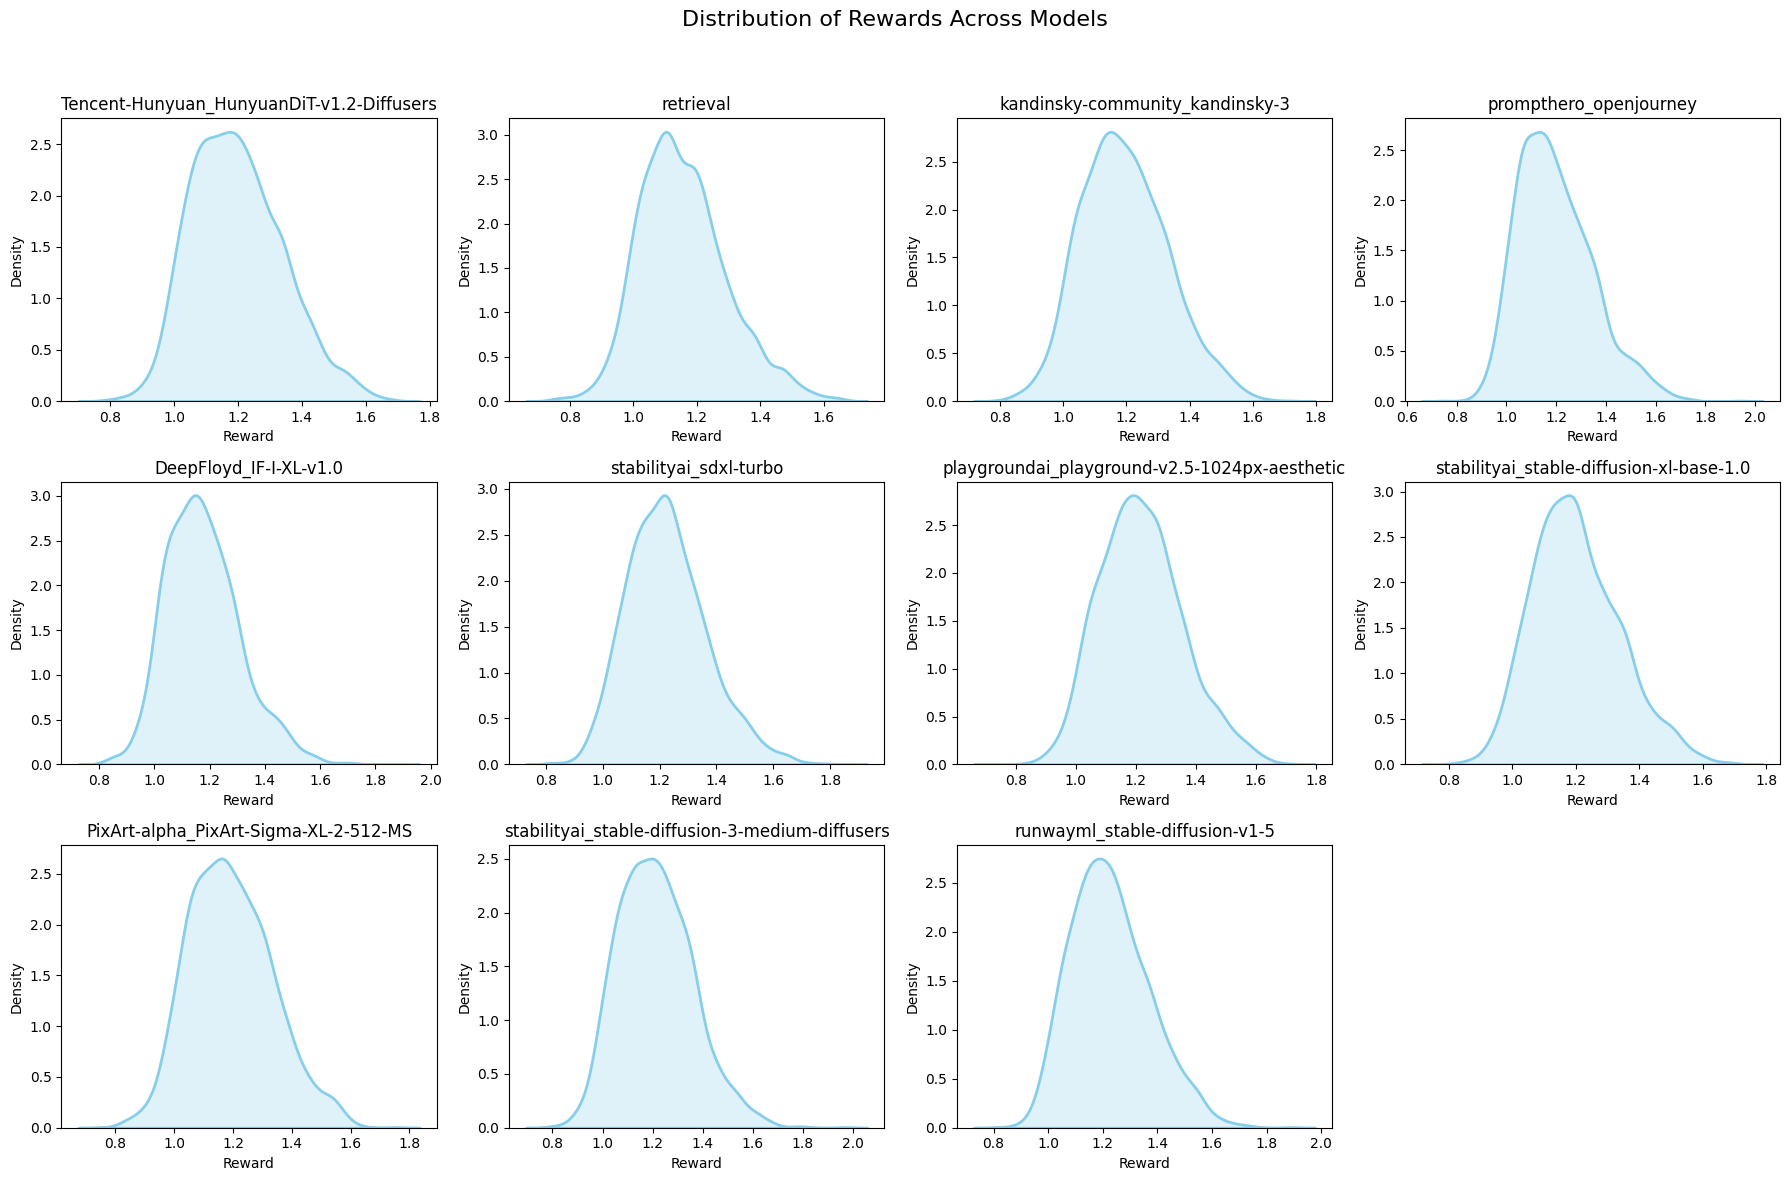

In [20]:
import pandas as pd
from tqdm import tqdm
import os
import torch
import pickle

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle('Distribution of Rewards Across Models', fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot each distribution on the corresponding subplot
for i, (k, v) in enumerate(dist_relation_lemma_max_cohyponym.items()):  # We plot only the first 9 as requested
    sns.kdeplot(v, ax=axes[i], fill=True, color="skyblue", linewidth=2)
    axes[i].set_title(k, fontsize=12)
    axes[i].set_xlabel('Reward', fontsize=10)
    axes[i].set_ylabel('Density', fontsize=10)

# Remove any empty subplots if we have less than 9 plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [32]:
def clean(synset):
    return synset.split('.')[0]

df['hypernym_synsets'] = df['hypernym_synsets'].apply(ast.literal_eval)
df['cohyponym_synsets'] = df['cohyponym_synsets'].apply(ast.literal_eval)

core = df['core_lemma'].values.tolist()

hypernyms = []
for elem in df['hypernym_synsets']:
    for hypernym in elem:
        hypernyms.append(clean(hypernym))

hypernyms = list(set(hypernyms))

cohyponym_synsets = []
for elem in df['cohyponym_synsets']:
    for cohyponym in elem:
        cohyponym_synsets.append(clean(cohyponym))

cohyponym_synsets = list(set(cohyponym_synsets))

In [35]:
cohyponym_synsets

['frizz',
 'animize',
 'feather',
 'skiffle',
 'triglochin',
 'influence',
 'de-escalation',
 'genus_sesbania',
 'shard',
 'flathead',
 'red_poll',
 'pyrrhotite',
 'synapsis',
 'aldehyde',
 'self-punishment',
 'pick',
 'venter',
 'piquancy',
 'depressor',
 'oleo_oil',
 'repel',
 'schizocarp',
 'stock_purchase_plan',
 'calcium_blocker',
 'korean',
 'gradate',
 'fictional_animal',
 'wounded',
 'charge',
 'periclase',
 'sandwich',
 'genus_arum',
 'beatification',
 'change_of_magnitude',
 'cam',
 'architrave',
 'partner',
 'nickname',
 'registered_security',
 'abalone',
 'savoyard',
 'fall',
 'industrial_union',
 'papaya',
 'bauxite',
 'self-improvement',
 'pendulum',
 'lungi',
 'suspend',
 'nursing',
 'thaw',
 'mixed_drink',
 'lacrimal_duct',
 'print_media',
 'breechcloth',
 'crack',
 'nephology',
 'croton_oil',
 'tree_shrew',
 'flatworm',
 'karakalpak',
 'surfeit',
 'antimycin',
 'playhouse',
 'distill',
 'constitutionalize',
 'revolutionist',
 'stoker',
 'complexifier',
 'apartment',
 '

In [26]:
df['hypernym_synsets']

0         [coinage.n.01]
1            [coin.n.01]
2            [coin.n.01]
3            [coin.n.01]
4            [coin.n.01]
              ...       
3365    [body_part.n.01]
3366       [player.n.01]
3367       [person.n.01]
3368         [part.n.03]
3369    [secretion.n.02]
Name: hypernym_synsets, Length: 3370, dtype: object